# Analysis Notebook

## Init

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

from models import *
from cosmology import CosmologyMCMC

In [15]:
file = 'data/DES-Dovekie_HD.csv'

with open(file) as f:
    for i, line in enumerate(f):
        if line.startswith('VARNAMES:'):
            header_line = line
            header_idx = i
            break

cols = header_line.replace("VARNAMES:", "").split()

df = pd.read_csv(file, sep='\s+', skiprows=header_idx + 1, header=None).iloc[:, 1:]
df.columns = cols

low_z = df[df['IDSURVEY'] != 10]
high_z = df[df['IDSURVEY'] == 10]
high_z

,CID,IDSURVEY,zHD,zHEL,MU,MUERR,MUERR_VPEC,MUERR_SYS,PROBIA_BEAMS
187,1371046,10,0.07334,0.07411,37.60807,0.1792,0.0307,0.39882,1.00000
188,1318737,10,0.07374,0.07451,37.36177,0.1858,0.0305,0.06818,1.00000
199,1864053,10,0.09333,0.09422,38.14556,0.0994,0.0243,0.06934,1.00000
200,1344303,10,0.09394,0.09475,38.19696,0.2395,0.0242,0.13223,0.99969
201,1317612,10,0.10442,0.10525,38.35683,0.1256,0.0218,0.02734,0.99996
...,...,...,...,...,...,...,...,...,...
1815,1263785,10,1.06420,1.06498,44.23028,0.1451,0.0028,0.03884,0.99765
1816,1842087,10,1.08349,1.08430,44.52159,0.1518,0.0027,0.13563,0.99789
1817,1339609,10,1.12132,1.12212,44.20175,0.1075,0.0026,0.06526,0.98858
1818,1446080,10,1.13057,1.13140,44.52710,0.1585,0.0026,0.11217,0.99945


Remove points with high MU uncertainty (above 0.4)

In [16]:
df = df[df['MUERR'] < 0.4]

low_z = low_z[low_z['MUERR'] < 0.4]
high_z = high_z[high_z['MUERR'] < 0.4]

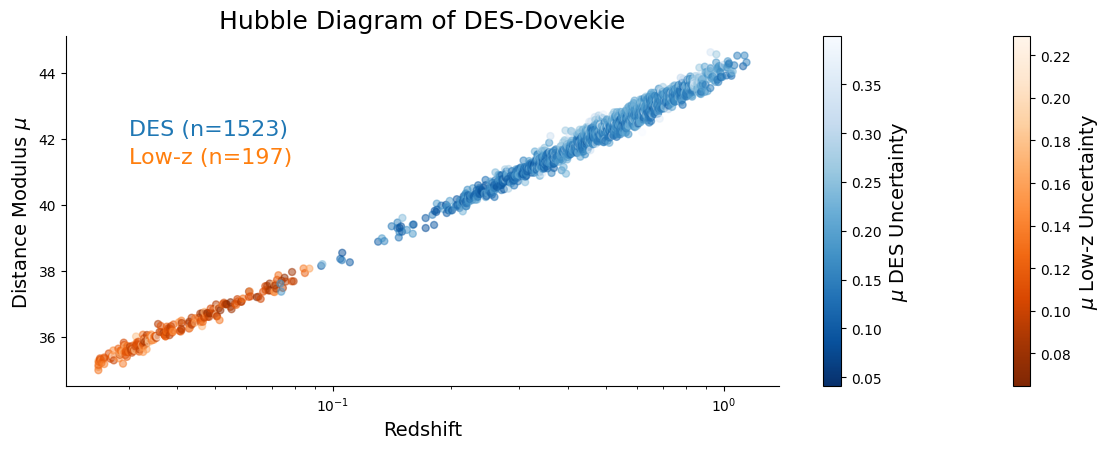

In [17]:
plt.figure(figsize=(12, 4.6))

plt.scatter(low_z['zHD'], low_z['MU'], c=low_z['MUERR'], s=25, cmap='Oranges_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ Low-z Uncertainty', size=14)
plt.scatter(high_z['zHD'], high_z['MU'], c=high_z['MUERR'], s=25, cmap='Blues_r', alpha=0.5)
cbar = plt.colorbar()
cbar.solids.set_alpha(1)
cbar.set_label('$\mu$ DES Uncertainty', size=14)


plt.xscale('log')
plt.ylabel('Distance Modulus $\mu$', size=14)
plt.xlabel('Redshift', size=14)
plt.title('Hubble Diagram of DES-Dovekie', size=18)
plt.text(0.03, 42, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
plt.text(0.03, 41.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Init and Load MCMC Chains

Load in all the burned data from the pickle files. Cannot use the actual samplers, but *__should__* be able to do anything you would normally do post burn-in.

In [18]:
lcdm_sampler = CosmologyMCMC(LambdaCDMModel(), df)
lcdm_sampler.burned = pd.read_pickle('cache/lcdm.pkl')
fwcdm_sampler = CosmologyMCMC(FlatwCDMModel(), df)
fwcdm_sampler.burned = pd.read_pickle('cache/fwcdm.pkl')
fw0wa_sampler = CosmologyMCMC(Flatw0waCDMModel(), df)
fw0wa_sampler.burned = pd.read_pickle('cache/fw0wa.pkl')
monly_sampler = CosmologyMCMC(MatterOnlyModel(), df)
monly_sampler.burned = pd.read_pickle('cache/monly.pkl')

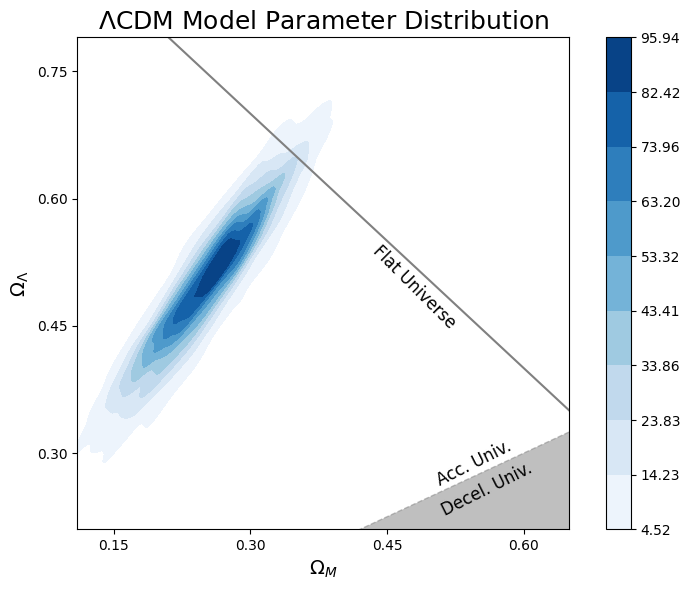

In [19]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_box_aspect(1) 

sns.kdeplot(x=lcdm_sampler.burned['Om_m'], y=lcdm_sampler.burned['Om_l'], cmap='Blues', fill=True, cbar=True)

X = np.linspace(0, 1, 100)
plt.plot(X, 1 - X, color='gray')
plt.fill_between(X, 0.5*X, color='gray', alpha=0.5, linestyle='dashed')

rotn = np.degrees(np.arctan2(1, 2))
plt.annotate('Acc. Univ.', xy=(0.545, 0.2875), ha='center', va='center', rotation=rotn, fontsize=12)
plt.annotate('Decel. Univ.', xy=(0.56, 0.2575), ha='center', va='center', rotation=rotn, fontsize=12)

rotn = np.degrees(np.arctan2(X[0]-X[1], X[1]-X[0]))
plt.annotate('Flat Universe', xy=(0.48, 0.495), ha='center', va='center', rotation=rotn, fontsize=12)

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\Omega_\Lambda$', size=14)
plt.xlim(0.11, 0.65)
plt.ylim(0.21, 0.79)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.15))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.15))
plt.title('$\Lambda$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()

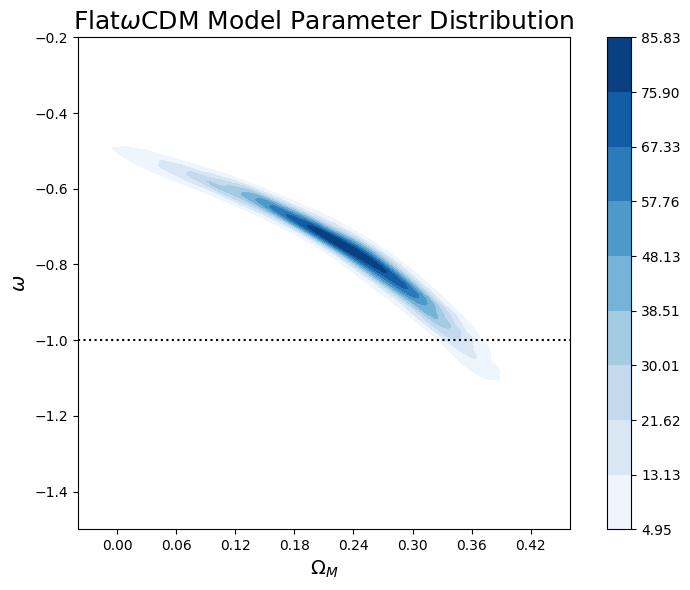

In [20]:
fig, ax = plt.subplots(figsize=(8,6))
ax.set_box_aspect(1) 

sns.kdeplot(fwcdm_sampler.burned, x='Om_m', y='w', cmap='Blues', fill=True, cbar=True)

plt.axhline(-1, color='black', linestyle='dotted')

plt.xlabel('$\Omega_M$', size=14)
plt.ylabel('$\omega$', size=14)
plt.xlim(-0.04, 0.46)
plt.ylim(-1.5, -0.2)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.06))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
plt.title('Flat$\omega$CDM Model Parameter Distribution', size=18)
plt.tight_layout()
plt.show()

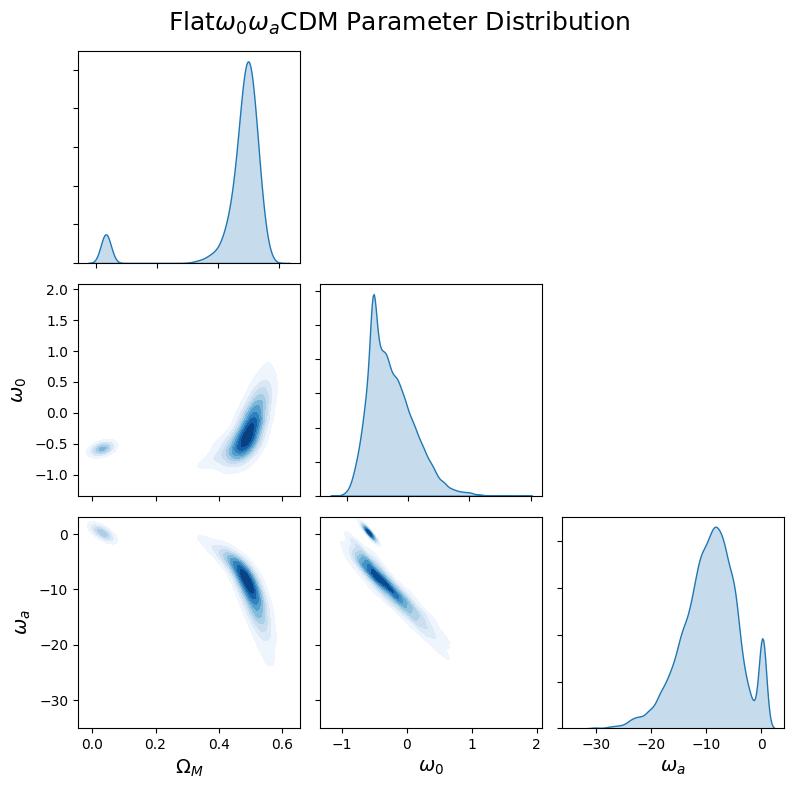

In [21]:
fig = plt.figure(figsize=(8, 8))

titles = ['Matter Density Parameter', 'w0', 'wa']
labels = [r'$\Omega_M$', r'$\omega_0$', r'$\omega_a$']

ndim = 3
for i in range (3):
    for j in range(3):
        if i >= j:
            ax = fig.add_subplot(ndim, ndim, i * ndim + j + 1)
        
        if i == j:
            sns.kdeplot(fw0wa_sampler.burned.iloc[:, i+1], cmap='Blues', fill=True)
        elif i > j:
            sns.kdeplot(x=fw0wa_sampler.burned.iloc[:, j+1], y=fw0wa_sampler.burned.iloc[:, i+1], cmap='Blues', fill=True)
            
        ax.set(xlabel=None, ylabel=None)
        
        if i < ndim - 1:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel(labels[j], size=14)
            
        if j > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(labels[i], size=14)

fig.suptitle('Flat$\omega_0\omega_a$CDM Parameter Distribution', size=18)
plt.tight_layout()
plt.show()

## Bringin' it all Together Now

these are just a couple of helper functions

In [ ]:
def weighted_mu(g):
    """Weighted averaging by uncertainty used for binning the raw data."""
    w = 1 / g['MUERR']**2
    mu = np.sum(w * g['MU']) / np.sum(w)
    mu_err = np.sqrt(1 / np.sum(w))
    return pd.Series({
        'zHD': g['zHD'].mean(),
        'MU': mu,
        'MUERR': mu_err,
        'N': len(g)
    })
    
def mu_to_lum_dist(MU):
    return 10**((MU - 25) / 5)

# def chi_squared(residuals, err):
#     residuals = self.data_df['MU'] - self.model.mu_model(params, self.data_df['zHD'])    
            
#     return (residuals / err) ** 2
    
def model_median(chain, func, z_grid, n=100, percentiles=False):
    """Compute the median best-fit line from n number of random parameter combinations along a sample chain. Optionally compute the 16 and 84 percentile bands."""
    models = chain.sample(n=n).apply(func, args=(z_grid,), axis=1)
    stacked = np.vstack(models)
    mu_med = np.median(stacked, axis=0)
    
    if percentiles:
        mu_16 = np.percentile(stacked, 16, axis=0)
        mu_84 = np.percentile(stacked, 84, axis=0)
        return mu_med, mu_16, mu_84
    
    return mu_med

In [28]:
z_grid = np.logspace(np.log10(df['zHD'].min()), np.log10(df['zHD'].max()), 200)

# compute the median of each model from n=100 random samples
lcdm_med, lcdm_16, lcdm_84 = model_median(lcdm_sampler.burned[['H_0', 'Om_m', 'Om_l']], lcdm_sampler.mu_model_corrected, z_grid, percentiles=True)
fwcdm_med = model_median(fwcdm_sampler.burned, fwcdm_sampler.mu_model_corrected, z_grid)
fw0wa_med = model_median(fw0wa_sampler.burned, fw0wa_sampler.mu_model_corrected, z_grid)
monly_med = model_median(monly_sampler.burned[['H_0', 'Om_m']], monly_sampler.mu_model_corrected, z_grid)

now its time to make some PLOTS

/tmp/ipykernel_1336000/1070568591.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['bin_id'] = data_df.index // 50


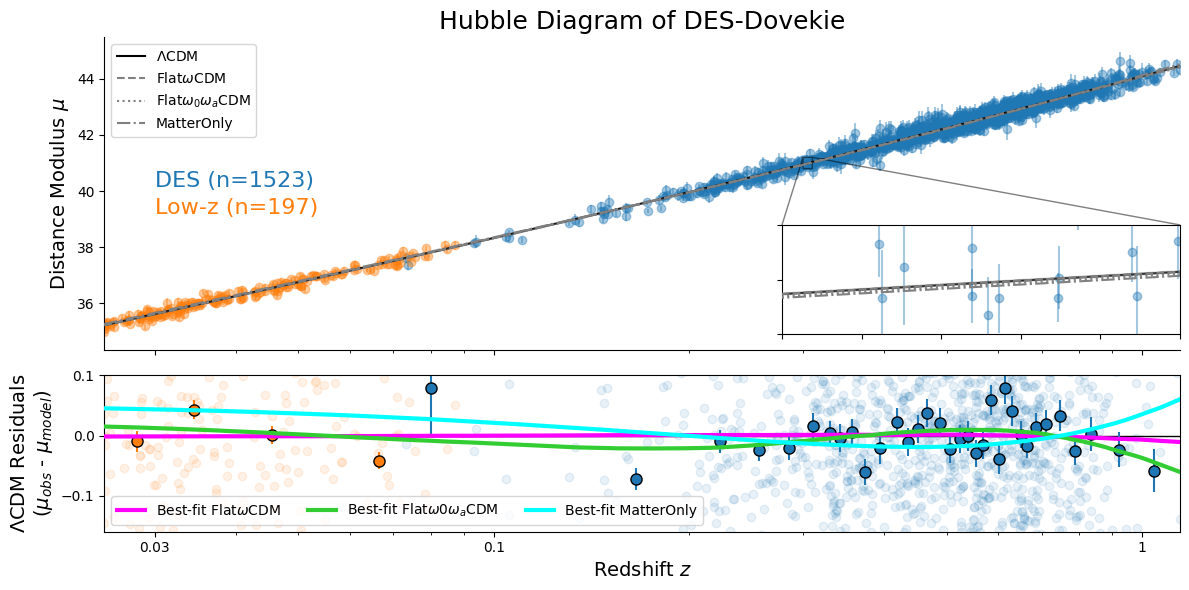

In [26]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# raw data
ax1.errorbar(
    high_z['zHD'], high_z['MU'],
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

ax1.errorbar(
    low_z['zHD'], low_z['MU'],
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

# LambdaCDM posterior band
ax1.plot(z_grid, lcdm_med, color='black', label='$\Lambda$CDM', zorder=9)
ax1.fill_between(z_grid, lcdm_16, lcdm_84, color='gray', alpha=0.3, zorder=9)

# comparison models
ax1.plot(z_grid, fwcdm_med, color='gray', linestyle='--', zorder=9, label='Flat$\omega$CDM')
ax1.plot(z_grid, fw0wa_med, color='gray', linestyle=':', zorder=9, label='Flat$\omega_0\omega_a$CDM')
ax1.plot(z_grid, monly_med, color='gray', linestyle='-.', zorder=9, label='MatterOnly')

# inset plot
# [x_start, y_start, width, height] in fractions of the main axes (0 to 1)
axins = ax1.inset_axes([0.63, 0.05, 0.37, 0.35], xlim=(.3, .31), ylim=(40.8, 41.2), xticklabels=[], yticklabels=[])
ax1.indicate_inset_zoom(axins, edgecolor="black")

# copy all the data into the inset plot
# raw data
axins.errorbar(
    high_z['zHD'], high_z['MU'],
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

axins.errorbar(
    low_z['zHD'], low_z['MU'],
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

# LambdaCDM posterior band
axins.plot(z_grid, lcdm_med, color='black', label='$\Lambda$CDM', zorder=9)
axins.fill_between(z_grid, lcdm_16, lcdm_84, color='gray', alpha=0.3, zorder=9)

# comparison models
axins.plot(z_grid, fwcdm_med, color='gray', linestyle='--', zorder=9, label='Flat$\omega$CDM')
axins.plot(z_grid, fw0wa_med, color='gray', linestyle=':', zorder=9, label='Flat$\omega_0\omega_a$CDM')
axins.plot(z_grid, monly_med, color='gray', linestyle='-.', zorder=9, label='MatterOnly')

# axes 2
ax2.axhline(0, color='black', lw=1) # zero line for reference

# loop through the low and high z datasets seperately so we can color code em (there is probably a better solution but meh...)
for i, data_df in enumerate([low_z, high_z]):
    mu_best = model_median(lcdm_sampler.burned[['H_0', 'Om_m', 'Om_l']], lcdm_sampler.mu_model_corrected, data_df['zHD'])
    residuals = data_df['MU'] - mu_best

    # background scatter plot
    ax2.scatter(
        data_df['zHD'],
        residuals,
        marker='o', alpha=0.1,
        color=f'C{1-i}' 
    )
    
    # making redshift bins of ~50 supernovae each for the residuals data
    data_df['bin_id'] = data_df.index // 50
    binned = data_df.groupby('bin_id').apply(weighted_mu, include_groups=False)
    mu_best = model_median(lcdm_sampler.burned[['H_0', 'Om_m', 'Om_l']], lcdm_sampler.mu_model_corrected, binned['zHD'])
    ax2.errorbar(binned['zHD'], binned['MU']-mu_best, yerr=binned['MUERR'], fmt='o', mec='black', markersize=8, color=f'C{1-i}')

# plot the residuals for (each individual model best-fit) - (LambdaCDM best-fit) to compare the models easily
lcdm_best = model_median(lcdm_sampler.burned[['H_0', 'Om_m', 'Om_l']], lcdm_sampler.mu_model_corrected, df['zHD'])
plt.plot(df['zHD'], 
         model_median(fwcdm_sampler.burned, fwcdm_sampler.mu_model_corrected, df['zHD']) - lcdm_best, 
         lw=3, color='magenta', label='Best-fit Flat$\omega$CDM', zorder=9)

plt.plot(df['zHD'], 
        model_median(fw0wa_sampler.burned, fw0wa_sampler.mu_model_corrected, df['zHD']) - lcdm_best, 
         lw=3, color='limegreen', label='Best-fit Flat$\omega0\omega_a$CDM', zorder=9)

plt.plot(df['zHD'], 
        model_median(monly_sampler.burned[['H_0', 'Om_m']], monly_sampler.mu_model_corrected, df['zHD']) - lcdm_best, 
         lw=3, color='cyan', label='Best-fit MatterOnly', zorder=9)

# axes 1 configurations
ax1.set_title('Hubble Diagram of DES-Dovekie', size=18)
ax1.set_ylabel('Distance Modulus $\mu$', size=14)
ax1.text(0.03, 40, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
ax1.text(0.03, 39.75, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
ax1.set_xscale('log')
ax1.legend(loc='upper left')
ax1.spines[['top', 'right']].set_visible(False)

# axes 2 configurations
ax2.set_ylim(-0.16, 0.1)
ax2.set_xlim(df['zHD'].min(), df['zHD'].max())
ax2.set_ylabel(r"$\Lambda$CDM Residuals"+"\n"+"($\mu_{obs}$ - $\mu_{model}$)", size=14)
ax2.set_xlabel('Redshift $z$', size=14)
ax2.legend(loc='lower left', ncols=3)
ax2.set_xticks([0.03, 0.1, 1], ['0.03', '0.1', '1'])

plt.tight_layout()
plt.show()

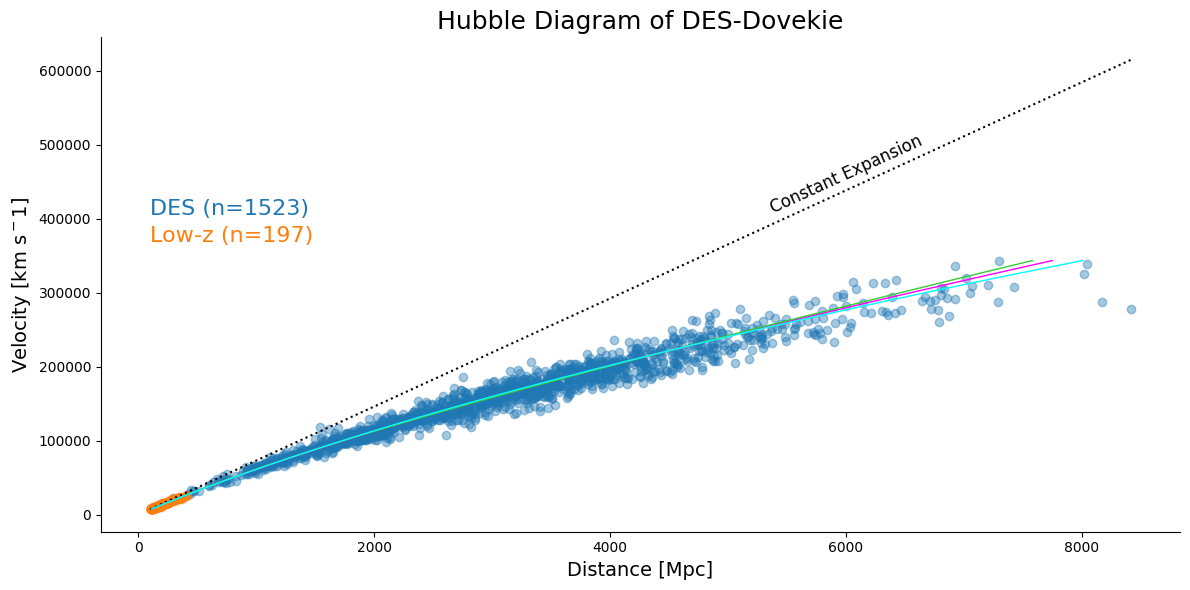

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# raw data
ax.errorbar(
    10**((high_z['MU']-25)/5), high_z['zHD'] * 3e5,
    yerr=high_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:blue'
)

ax.errorbar(
    10**((low_z['MU']-25)/5), low_z['zHD'] * 3e5,
    yerr=low_z['MUERR'],
    fmt='o', alpha=0.4, color='tab:orange'
)

d_grid = np.linspace(np.min(10**((df['MU']-25)/5)), np.max(10**((df['MU']-25)/5)), 200)
ax.plot(d_grid, d_grid * 73, linestyle='dotted', color='black', zorder=9)

ax.plot(mu_to_lum_dist(model_median(fwcdm_sampler.burned, fwcdm_sampler.mu_model_corrected, df['zHD'])),
        df['zHD']*3e5,  
        lw=1, color='magenta', label='Best-fit Flat$\omega$CDM', zorder=9)

ax.plot(mu_to_lum_dist(model_median(fw0wa_sampler.burned, fw0wa_sampler.mu_model_corrected, df['zHD'])),
        df['zHD']*3e5,  
        lw=1, color='limegreen', label='Best-fit Flat$\omega0\omega_a$CDM', zorder=9)

ax.plot(mu_to_lum_dist(model_median(monly_sampler.burned[['H_0', 'Om_m']], monly_sampler.mu_model_corrected, df['zHD'])), 
        df['zHD']*3e5,
        lw=1, color='tab:cyan', label='Best-fit MatterOnly', zorder=9)

rotn = np.degrees(np.arctan2(73*(d_grid[1]-d_grid[0]), d_grid[1]-d_grid[0]))
ax.annotate('Constant Expansion', xy=(6000, 4.6e5), ha='center', va='center', rotation=rotn, transform_rotates_text=True, fontsize=12)

ax.set_ylabel('Velocity [km s$^-1$]', size=14)
ax.set_xlabel('Distance [Mpc]', size=14)
ax.set_title('Hubble Diagram of DES-Dovekie', size=18)
ax.text(100, 4e5, f"DES (n={len(high_z)})", color='tab:blue', size=16, ha='left', va='bottom')
ax.text(100, 3.9e5, f"Low-z (n={len(low_z)})", color='tab:orange', size=16, ha='left', va='top')
# ax.legend(loc='upper left')

ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:
df = df.sort_values('zHD') # make sure they are sorted by their z value

# compute the MU values for each model
df['mu_lcdm'] = model_median(lcdm_sampler.burned[['H_0', 'Om_m', 'Om_l']], lcdm_sampler.mu_model_corrected, df['zHD'])
df['mu_fwcdm'] = model_median(fwcdm_sampler.burned, fwcdm_sampler.mu_model_corrected, df['zHD'])
df['mu_fw0wa'] = model_median(fw0wa_sampler.burned, fw0wa_sampler.mu_model_corrected, df['zHD'])
df['mu_monly'] = model_median(monly_sampler.burned[['H_0', 'Om_m']], monly_sampler.mu_model_corrected, df['zHD'])

# chi^2 for each model
df['chi2_lcdm'] = (((df["MU"] - df["mu_lcdm"]) / df["MUERR"])**2)
df['chi2_fwcdm'] = (((df["MU"] - df["mu_fwcdm"]) / df["MUERR"])**2)
df['chi2_fw0wa'] = (((df["MU"] - df["mu_fw0wa"]) / df["MUERR"])**2)
df['chi2_monly'] = (((df["MU"] - df["mu_monly"]) / df["MUERR"])**2)

# cumulative sum of chi^2 for each model
df['cum_chi2_lcdm'] =  df['chi2_lcdm'].cumsum()
df['cum_chi2_fwcdm'] = df['chi2_fwcdm'].cumsum()
df['cum_chi2_fw0wa'] = df['chi2_fw0wa'].cumsum()
df['cum_chi2_monly'] = df['chi2_monly'].cumsum()

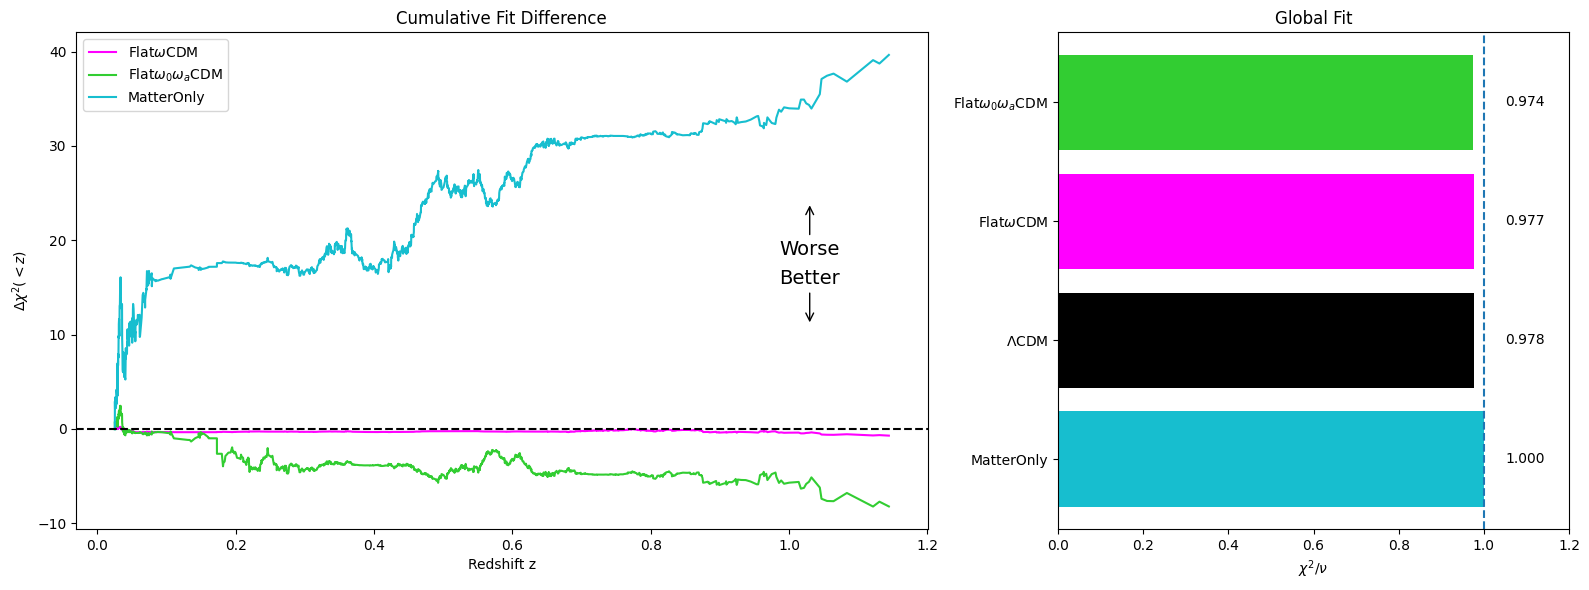

In [120]:
# degrees of freedom = (# of samples) - (# of parameters)
chi2_lcdm  = df['chi2_lcdm'].sum() / (len(df) - lcdm_sampler.model.ndim)
chi2_fwcdm = df['chi2_fwcdm'].sum() / (len(df) - fwcdm_sampler.model.ndim)
chi2_fw0wa = df['chi2_fw0wa'].sum() / (len(df) - fw0wa_sampler.model.ndim)
chi2_monly = df['chi2_monly'].sum() / (len(df) - monly_sampler.model.ndim)

results = pd.DataFrame({
    'model': ['$\Lambda$CDM', 'Flat$\omega$CDM', 'Flat$\omega_0\omega_a$CDM', 'MatterOnly'],
    # 'chi2': [df['chi2_lcdm'].sum(), df['chi2_fwcdm'].sum(), df['chi2_fw0wa'].sum(), df['chi2_monly'].sum()],
    'red_chi2': [chi2_lcdm, chi2_fwcdm, chi2_fw0wa, chi2_monly]
})

# cumulative sum DELTA to lambda CDM model
df[f"d_cum_fwcdm"] = df[f"cum_chi2_fwcdm"] - df[f"cum_chi2_lcdm"]
df[f"d_cum_fw0wa"] = df[f"cum_chi2_fw0wa"] - df[f"cum_chi2_lcdm"]
df[f"d_cum_monly"] = df[f"cum_chi2_monly"] - df[f"cum_chi2_lcdm"]
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.5, 1.5]})

# delta cumulative chi^2
ax1.plot(df['zHD'], df['d_cum_fwcdm'], color='magenta', label='Flat$\omega$CDM')
ax1.plot(df['zHD'], df['d_cum_fw0wa'], color='limegreen', label='Flat$\omega_0\omega_a$CDM')
ax1.plot(df['zHD'], df['d_cum_monly'], color='tab:cyan', label='MatterOnly')

ax1.annotate(
    'Worse',
    xy=(df['zHD'].max()*0.9, 24),
    xytext=(df['zHD'].max()*0.9, 18),
    arrowprops=dict(arrowstyle='->'),
    ha='center',
    va='bottom',
    size=14
)

ax1.annotate(
    'Better',
    xy=(df['zHD'].max()*0.9, 11),
    xytext=(df['zHD'].max()*0.9, 17),
    arrowprops=dict(arrowstyle='->'),
    ha="center",
    va='top',
    size=14
)

ax1.axhline(0, linestyle="--", color='black')
ax1.set_xlabel("Redshift z")
ax1.set_ylabel(r"$\Delta \chi^2(<z)$")
ax1.set_title("Cumulative Fit Difference")
ax1.legend()

results = results.sort_values('red_chi2', ascending=False)
ax2.barh(results['model'], results['red_chi2'], color=['tab:cyan', 'black', 'magenta', 'limegreen'])

ax2.axvline(1, linestyle="--")
ax2.set_xlabel(r"$\chi^2 / \nu$")
ax2.set_title("Global Fit")
ax2.set_xlim(0, 1.2)

for i, v in enumerate(results["red_chi2"]):
    ax2.text(1.05, i, f"{v:.3f}", va='center')

plt.tight_layout()
plt.show()